# Sidewalk/road classification using deep learning methods

## 0 Theory

Before we begin to implement deep learning algorithms to our data, it makes sense to understand what is in the literature. This way, we can get a grasp of the accuracy and availability of different usable models.

Based on a quick search, PointNet++ as a segmentation model appears to be popular for classifying sidewalks (Hou and Ai, 2020). PointNet++ automatically learns local geometry intrinsically, learning increasingly abstract features. CNN semantic segmentation was inaccurate in Hou and Ai (2020) because there are small elevation offsets, where CNN algorithms struggle. This is relevant for our case too. However, they trained their PointNet++ on Semantic3D. One important thing to be said here is that they use DL to simplify the geometry problem, not classify.

The part of this analyis that changes throughout the DL papers is not necessarily the segmentation, but how sidewalks are differentiated by their environment. Sidewalks can also be differentiated through subtle jumps in elevation (Horváth et al., 2021).

## 1 Methodological concepts

### 1.1. Graph based segmentation
Theoretically similar, but methodologically different, is graph based segmentation. This is - instead of treating points independently of one another, or slicing into representative stripes, the points are treated as nodes, and their connections as edges. This is useful because the computation of sidewalk vs road is not just a one point property, but a property of a region, a connected surface, and a continuous structure, hence the planing method describes earlier. With graphs, you can encode spatial continuity, smoothness constraints, label consistency, and boundary detection.

Graph segmentation splits nodes into groups such that their connections within groups are strong, and across groups is weak. Strong here can be defined on distance, normal similarity, height difference, learned embedding similarity, and semantic probabilities.

There are 3 general styles of graph based segmentation:

#### Classical graph cuts

Where: Each edge has an assigned weight. the weight is high if points are similar, and low if they are different. You then calculate a partition that minimises the cost.

#### Region growing

Starting from seed points, grow the region while keeping the normal similarity below a threshold, keeping height difference small, and curvature small. This is essentially plane/surface growing. Likely intuitive for sidewalks

#### Graph neural networks

This involves 1. Building a k-NN graph; 2. assigning features to nodes; 3. letting the network propagate features across edges; and 4. Predicting labels. Let's run through a quick example of how we'd do this:

##### Step 1 Preprocessing
- Compute per-point features:
- Coordinates
- Normals (via PCA)
- Curvature
- Height above ground
- Learned embedding

##### Step 2 build Knn graph
Each point connects to 20 nearest neighbors. Edges store:
- Distance
- Normal angle difference
- Height difference

##### Step 3 Define similarity metric

Two points are “similar” if:
- Normals aligned
- Height difference small
- Spatially close

Edge weight = combination of these.

##### Step 4 Cluster Graph

Use:
- Region growing
- Spectral clustering
- Or graph cut

To create connected planar patches so that the sidewalk becomes a large planar cluster at consistent elevation.

##### Step 5 Add a learned classifier

Cluster-level features:
- Area
- Mean normal
- Elevation offset from road
- Texture stats

Now classify cluster as:
- Road
- Sidewalk
- Roof
- Plaza
- Etc.

### 1.2. stripe-based classification

Point counts can quickly ramp up, so dividing the space into voxels (if necessary) aids with computation times. Voxels keep the LiDAR structure, random sampling removes the density consistency. Then you can sample and complete computations per voxel.

Adaptive sampling per voxel can observe is a surface is flat using PCA eigenvalues, whereby a small variation along a normal direction = a flat surface.

A label interpolation technique is required after PointNet++ prediction as there are sparse labels (i.e. 6 classes such as manmade infrastructure). So an interpolation technique based on finding neighbours using a hybrid k-nn + radius assigns a label. The radius alone would not find close neighbours in sparse regions.

Hou and Ai (2020) use stripe-based sidewalk extraction. This is geometry based where we need to separate sidewalk points from roads and grass using what we know as sidewalk characteristics (Flat, continuous, planar, consistent normal). The stripe technique (in this case, every 3ft) makes local geometry easier to reason, avoiding long range distortion of geometry.

### 0.1.1 Stripe processing

Stripe processing has two phases: Splitting and Merging.

#### Splitting (Octree + PCA)

For splitting, put each stripe into an octree, and for each node compute the PCA and check if the points are co-planar. If they are not coplanar, split into 8 smaller cubes and repeat until each node satisfies:

 $ λ_min ​≤ Δ $

 Where:
 - $λ_min$ = smallest eigenvalue of covariance
 - $Δ$ = tolerance (given measurement)

 So - Eigenvalue along normal direction = thickness of the plane. If thickness is small enough then we accept this as the plane.


#### Merging

After splitting, you have many small planar patches, if neighbouring patches have similar normals and marging still satisfies the coplanar criterion then they stay merged, therefore you have large planar surfaces inside the stripe. This works because sidewalks tend to be planar, smooth and consistent normal, whereas grass is bumpy, irregular and contains larger variation in eigenvalues.

# Code

In [18]:
import os
import sys
import random
from pathlib import Path

import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

WORKSPACE_ROOT = Path.cwd()
if not (WORKSPACE_ROOT / "src").exists() and (WORKSPACE_ROOT.parent / "src").exists():
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

import src.carriageway_focus_utils as cfu

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("/media/HDD_disk/james/lidar_REALLOCATE")
N_SAMPLE_PER_CITY = 750_000

TARGET_CLASSES = {0: "other", 2: "sidewalk", 11: "street"}
CLASS_ORDER = [0, 2, 11]

# Segment controls
VOXEL_SIZE = 0.6
MIN_POINTS_PER_SEG = 8
N_CONTEXT_NEIGHBORS = 8

print("Seed:", SEED)
print("Workspace:", WORKSPACE_ROOT)
print("Data path:", DATA_PATH)
print("Number of samples per city:", N_SAMPLE_PER_CITY)

Seed: 42
Workspace: /media/M2_disk/james/REALLOCATE/lidar_sidewalks
Data path: /media/HDD_disk/james/lidar_REALLOCATE
Number of samples per city: 750000


## Preprocessing

In [19]:
CITY_FILES = {
    "Riga": DATA_PATH / "riga.laz",
    "Utrecht": DATA_PATH / "utrecht.laz",
    "Vilnius": DATA_PATH / "vilnius.laz",
    "Warsaw": DATA_PATH / "warsaw.laz",
}

city_las = {name: laspy.read(path) for name, path in CITY_FILES.items()}
print("Loaded cities:", list(city_las.keys()))

# Remap IFP codes → 3-class scheme.
# IFP class 0 in the raw data means "not yet classified" — it is NOT the same
# as our "other" category.  This function collapses every code that isn't
# sidewalk (2) or street (11) into 0, making 0 the correct catch-all "other".
def remap_labels(raw_labels: np.ndarray) -> np.ndarray:
    out = np.zeros_like(raw_labels, dtype=np.int32)
    out[raw_labels == 2]  = 2
    out[raw_labels == 11] = 11
    return out

for name, las in city_las.items():
    remapped = remap_labels(np.asarray(las.classification))
    classes, counts = np.unique(remapped, return_counts=True)
    c = dict(zip(classes.tolist(), counts.tolist()))
    print(f"{name}: other={c.get(0,0):,}, sidewalk={c.get(2,0):,}, street={c.get(11,0):,}")

Loaded cities: ['Riga', 'Utrecht', 'Vilnius', 'Warsaw']
Riga: other=18,105,931, sidewalk=1,750,164, street=2,574,596
Utrecht: other=24,767,576, sidewalk=0, street=0
Vilnius: other=26,932,382, sidewalk=2,738,424, street=3,909,593
Warsaw: other=11,692,758, sidewalk=2,591,247, street=2,874,303


#### CRS check

In [ ]:
for name, las in city_las.items():
    crs = las.header.parse_crs()
    print(f"scales for {name}:", las.header.scales)   # precision (e.g. 0.001)
    print(f"crs for {name}:", crs)
    if crs:
        for ax in crs.axis_info:
            print(f"{ax.name} for {name}:", ax.unit_name, ax.unit_conversion_factor)


LAS file: Bologna
Point Format: <PointFormat(3, 4 bytes of extra dims)>
Number of Points: 112787346
Available Dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'height_division']
Bounding Box:
  X: -319.2701 to -107.22720000000001
  Y: -315.29970000000003 to 26.5196
  Z: -8.614600000000001 to 34.2946
Scale: [0.0001 0.0001 0.0001]
Offset: [0. 0. 0.]
CRS: None

LAS file: Riga
Point Format: <PointFormat(3, 4 bytes of extra dims)>
Number of Points: 65883275
Available Dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'height_division']
Bounding Box:
  X: -57.384

## STEP 2 — Adaptive Downsampling

We skip Step 1 and go straight to density-aware voxel downsampling.

Rule:
- `voxel_size = 3 × median NN distance`

Workflow:
1. Pick one city (start with Riga)
2. Estimate median nearest-neighbor distance from a random sample
3. Compute adaptive voxel size
4. Downsample with Open3D
5. Report compression ratio and resulting point count

Target guideline:
- Very large clouds (10M+) should often reduce toward ~1–2M points for fast experimentation.

In [7]:
import open3d as o3d
from sklearn.neighbors import NearestNeighbors

# Choose city for step-by-step development
CITY_FOR_STEP2 = "Riga"
las_step2 = city_las[CITY_FOR_STEP2]

# Raw points
xyz_raw = np.column_stack([las_step2.x, las_step2.y, las_step2.z]).astype(np.float64)
N_raw = len(xyz_raw)

# Estimate median NN distance from a random sample (fast + robust)
rng = np.random.default_rng(SEED)
nn_sample_n = min(200_000, N_raw)
idx = rng.choice(N_raw, size=nn_sample_n, replace=False)
xyz_nn = xyz_raw[idx]

# 2-NN because nearest point is itself (distance 0)
nn = NearestNeighbors(n_neighbors=2, algorithm="kd_tree", n_jobs=-1)
nn.fit(xyz_nn)
dists, _ = nn.kneighbors(xyz_nn)
median_nn = float(np.median(dists[:, 1]))

# Adaptive voxel rule from your plan
voxel_size_adaptive = 3.0 * median_nn

# Build Open3D cloud and downsample
pcd_raw = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(xyz_raw))
pcd_down = pcd_raw.voxel_down_sample(voxel_size=voxel_size_adaptive)

N_down = np.asarray(pcd_down.points).shape[0]
ratio = N_down / N_raw

print(f"STEP 2 completed for {CITY_FOR_STEP2}")
print(f"Raw points: {N_raw:,}")
print(f"Median NN distance: {median_nn:.6f}")
print(f"Adaptive voxel size (3x): {voxel_size_adaptive:.6f}")
print(f"Downsampled points: {N_down:,}")
print(f"Compression ratio: {ratio:.4f} ({100*ratio:.2f}% of original)")

# Keep these for next steps
xyz_step2 = np.asarray(pcd_down.points)
print("xyz_step2 ready for STEP 3 (neighborhood structure).")

STEP 2 completed for Riga
Raw points: 22,430,691
Median NN distance: 0.125675
Adaptive voxel size (3x): 0.377024
Downsampled points: 197,991
Compression ratio: 0.0088 (0.88% of original)
xyz_step2 ready for STEP 3 (neighborhood structure).


### STEP 2b — Auto-select voxel size per city

This helper chooses a practical voxel size automatically per city by:

1. Estimating nearest-neighbour spacing on a sample
2. Building a base voxel from a robust percentile (`p25`, not median)
3. Clamping to a curb-safe range (`0.03–0.10 m` by default)
4. Optionally nudging voxel up/down to hit a target point ratio band

This gives a transferable default that avoids over-aggressive downsampling.

In [20]:
def suggest_voxel_size_for_city(
    las,
    city_name: str,
    nn_sample_n: int = 200_000,
    percentile: float = 25.0,
    multiplier: float = 3.0,
    min_voxel: float = 0.03,
    max_voxel: float = 0.10,
    target_ratio_low: float = 0.04,
    target_ratio_high: float = 0.12,
    random_state: int = 42,
):
    """
    Suggest a practical voxel size for TLS downsampling with clear, curb-safe defaults.

    Why these defaults?
    -------------------
    - nn_sample_n=200_000:
      Large enough to estimate spacing robustly, small enough to stay fast on big clouds.

    - percentile=25 (p25, not median):
      Global median NN distance is often inflated by sparse/occluded areas.
      p25 better reflects denser street-surface regions we care about.

    - multiplier=3.0:
      Converts local spacing into a smoothing/downsampling scale that reduces redundancy
      while usually preserving surface topology.

    - min_voxel=0.03 m, max_voxel=0.10 m:
      Curb-relevant guardrails. Sidewalk-road boundaries are often ~5–25 cm height change;
      going much above 10 cm risks blurring curb detail, going below 3 cm can be expensive.

    - target_ratio_low/high = 0.04/0.12:
      Soft target: keep ~4–12% of original points after voxelization for iterative research.
      Not a hard rule; only used for a small one-step nudge.

    Returns
    -------
    dict with:
      city, n_raw,
      nn_p10/nn_p25/nn_p50,
      voxel_suggested,
      n_down, ratio,
      pcd_down, xyz_down
    """
    xyz = np.column_stack([las.x, las.y, las.z]).astype(np.float64)
    n_raw = len(xyz)

    rng = np.random.default_rng(random_state)
    idx = rng.choice(n_raw, size=min(nn_sample_n, n_raw), replace=False)
    xyz_nn = xyz[idx]

    nn = NearestNeighbors(n_neighbors=2, algorithm="kd_tree", n_jobs=-1)
    nn.fit(xyz_nn)
    d, _ = nn.kneighbors(xyz_nn)
    nn_d = d[:, 1]

    p_val = float(np.percentile(nn_d, percentile))
    voxel = float(np.clip(multiplier * p_val, min_voxel, max_voxel))

    pcd_raw_local = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(xyz))
    pcd_down_local = pcd_raw_local.voxel_down_sample(voxel_size=voxel)
    n_down = int(np.asarray(pcd_down_local.points).shape[0])
    ratio = n_down / n_raw

    # Lightweight ratio nudge if extremely dense/sparse after first pass
    target_mid = (target_ratio_low + target_ratio_high) / 2.0

    if ratio < target_ratio_low:
        voxel_try = max(min_voxel, voxel * 0.8)
        pcd_try = pcd_raw_local.voxel_down_sample(voxel_size=voxel_try)
        n_try = int(np.asarray(pcd_try.points).shape[0])
        ratio_try = n_try / n_raw
        if abs(ratio_try - target_mid) < abs(ratio - target_mid):
            voxel, pcd_down_local, n_down, ratio = voxel_try, pcd_try, n_try, ratio_try

    elif ratio > target_ratio_high:
        voxel_try = min(max_voxel, voxel * 1.2)
        pcd_try = pcd_raw_local.voxel_down_sample(voxel_size=voxel_try)
        n_try = int(np.asarray(pcd_try.points).shape[0])
        ratio_try = n_try / n_raw
        if abs(ratio_try - target_mid) < abs(ratio - target_mid):
            voxel, pcd_down_local, n_down, ratio = voxel_try, pcd_try, n_try, ratio_try

    return {
        "city": city_name,
        "n_raw": n_raw,
        "nn_p10": float(np.percentile(nn_d, 10)),
        "nn_p25": float(np.percentile(nn_d, 25)),
        "nn_p50": float(np.percentile(nn_d, 50)),
        "voxel_suggested": float(voxel),
        "n_down": int(n_down),
        "ratio": float(ratio),
        "pcd_down": pcd_down_local,
        "xyz_down": np.asarray(pcd_down_local.points),
    }


# Run suggestions for all loaded cities
voxel_suggestions = {}
rows = []
for city_name, las_obj in city_las.items():
    result = suggest_voxel_size_for_city(las_obj, city_name, random_state=SEED)
    voxel_suggestions[city_name] = result
    rows.append({
        "city": result["city"],
        "n_raw": result["n_raw"],
        "nn_p10": result["nn_p10"],
        "nn_p25": result["nn_p25"],
        "nn_p50": result["nn_p50"],
        "voxel_suggested": result["voxel_suggested"],
        "n_down": result["n_down"],
        "ratio": result["ratio"],
    })

voxel_df = pd.DataFrame(rows).sort_values("city").reset_index(drop=True)
display(voxel_df)

# Use Riga as working default for next step (change city name if needed)
CITY_FOR_STEP2 = "Riga"
voxel_size_adaptive = voxel_suggestions[CITY_FOR_STEP2]["voxel_suggested"]
pcd_down = voxel_suggestions[CITY_FOR_STEP2]["pcd_down"]
xyz_step2 = voxel_suggestions[CITY_FOR_STEP2]["xyz_down"]

print(f"Selected city for pipeline continuation: {CITY_FOR_STEP2}")
print(f"Adaptive voxel size: {voxel_size_adaptive:.5f}")
print(f"Points after downsampling: {len(xyz_step2):,}")
print("xyz_step2 ready for STEP 3 (neighborhood structure).")

,city,n_raw,nn_p10,nn_p25,nn_p50,voxel_suggested,n_down,ratio
0,Riga,22430691,0.054185,0.083020,0.125675,0.1,2856634,0.127354
1,Utrecht,24767576,0.066249,0.108033,0.170700,0.1,4242378,0.171288
2,Vilnius,33580399,0.069645,0.110856,0.176713,0.1,4987489,0.148524
3,Warsaw,17158308,0.045113,0.069532,0.106603,0.1,1781601,0.103833


Selected city for pipeline continuation: Riga
Adaptive voxel size: 0.10000
Points after downsampling: 2,856,634
xyz_step2 ready for STEP 3 (neighborhood structure).


## STEP 3 — Neighborhood Structure (core)

In this step we prepare neighborhood lookup structures once, so later feature computation is fast and consistent.

What we do:

1. Build a single global KD-tree on `xyz_step2`
2. Compute per-point local nearest-neighbor spacing
3. Convert spacing to adaptive radii with:
   - `radius_i = 5 × local_nn_i`
4. Clamp radii to practical bounds for stability

Outputs from this step:
- `pcd_step3` and `pcd_tree_step3` (Open3D KD-tree)
- `local_nn_step3` (per-point local spacing)
- `adaptive_radius_step3` (per-point neighborhood radii)
- `nn_idx_step3`, `nn_dist_step3` (k-NN structure for later steps)

These are the core inputs for Step 4 (eigenvalue geometry features).

In [21]:
# STEP 3 implementation
from sklearn.neighbors import NearestNeighbors
import open3d as o3d

# Ensure Step 2 output exists
if "xyz_step2" not in globals() or len(xyz_step2) == 0:
    raise RuntimeError("xyz_step2 not found. Run STEP 2 / STEP 2b first.")

# --- Core controls for neighborhood structure ---
K_NEIGHBORS_STEP3 = 20       # k-NN graph size used by later feature computation
RADIUS_FACTOR_STEP3 = 5.0    # adaptive radius rule: radius = factor * local NN distance
RADIUS_MIN_STEP3 = max(0.03, voxel_size_adaptive * 1.0)
RADIUS_MAX_STEP3 = max(0.15, voxel_size_adaptive * 6.0)

xyz_step3 = xyz_step2.astype(np.float64)
n_step3 = len(xyz_step3)

# 1) Global KD-tree (Open3D) built once
pcd_step3 = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(xyz_step3))
pcd_tree_step3 = o3d.geometry.KDTreeFlann(pcd_step3)

# 2) k-NN structure (scikit-learn, fast batched query)
knn_step3 = NearestNeighbors(n_neighbors=K_NEIGHBORS_STEP3 + 1, algorithm="kd_tree", n_jobs=-1)
knn_step3.fit(xyz_step3)

nn_dist_all, nn_idx_all = knn_step3.kneighbors(xyz_step3)
# Remove self-neighbor at column 0
nn_dist_step3 = nn_dist_all[:, 1:]
nn_idx_step3 = nn_idx_all[:, 1:]

# 3) Local spacing + adaptive radius per point
local_nn_step3 = nn_dist_step3[:, 0]
adaptive_radius_step3 = np.clip(
    RADIUS_FACTOR_STEP3 * local_nn_step3,
    RADIUS_MIN_STEP3,
    RADIUS_MAX_STEP3,
)

# Diagnostics
print("STEP 3 completed")
print(f"Points in working cloud: {n_step3:,}")
print(f"k-NN size: {K_NEIGHBORS_STEP3}")
print(f"Radius factor: {RADIUS_FACTOR_STEP3}")
print(f"Radius clamp: [{RADIUS_MIN_STEP3:.4f}, {RADIUS_MAX_STEP3:.4f}]")
print("Local NN distance percentiles:")
for p in [5, 25, 50, 75, 95]:
    print(f"  p{p:>2}: {np.percentile(local_nn_step3, p):.5f}")
print("Adaptive radius percentiles:")
for p in [5, 25, 50, 75, 95]:
    print(f"  p{p:>2}: {np.percentile(adaptive_radius_step3, p):.5f}")

print("\nObjects ready for STEP 4:")
print("- pcd_tree_step3 (Open3D KD-tree)")
print("- nn_idx_step3, nn_dist_step3 (k-NN graph)")
print("- local_nn_step3, adaptive_radius_step3 (per-point scale)")

STEP 3 completed
Points in working cloud: 2,856,634
k-NN size: 20
Radius factor: 5.0
Radius clamp: [0.1000, 0.6000]
Local NN distance percentiles:
  p 5: 0.03311
  p25: 0.05405
  p50: 0.06736
  p75: 0.08093
  p95: 0.09770
Adaptive radius percentiles:
  p 5: 0.16556
  p25: 0.27027
  p50: 0.33678
  p75: 0.40466
  p95: 0.48848

Objects ready for STEP 4:
- pcd_tree_step3 (Open3D KD-tree)
- nn_idx_step3, nn_dist_step3 (k-NN graph)
- local_nn_step3, adaptive_radius_step3 (per-point scale)


## STEP 4 — Eigenvalue Geometry Features

Now we turn each point's neighborhood into shape measurements.

For each point we:

1. Take its nearby neighbors from Step 3
2. Build a covariance matrix of that local 3-D neighborhood
3. Compute eigenvalues and eigenvectors
4. Convert those into geometric descriptors

Features we compute:
- `linearity`
- `planarity`
- `scattering`
- `curvature`
- `verticality`
- `roughness`
- plus the raw eigenvalues and the estimated local normal

**Important note:** we will first run this on a manageable sample of the downsampled cloud, not the full 2.8M points. That lets us validate the feature definitions and runtime before scaling up.

In [22]:
from joblib import Parallel, delayed


def _compute_one_point_geometry(i, xyz, nn_idx, nn_dist, adaptive_radius, eps=1e-12):
    """Compute local PCA/eigenvalue features for one point."""
    # keep only neighbors inside this point's adaptive radius
    mask = nn_dist[i] <= adaptive_radius[i]
    neigh_idx = nn_idx[i][mask]

    # fallback: if adaptive radius is too small, keep at least first 6 neighbors
    if neigh_idx.size < 6:
        neigh_idx = nn_idx[i][: min(6, nn_idx.shape[1])]

    pts = xyz[neigh_idx]
    center = pts.mean(axis=0)
    X = pts - center

    # covariance and eigendecomposition
    C = (X.T @ X) / max(len(pts), 1)
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]  # descending: l1 >= l2 >= l3
    evals = np.maximum(evals[order], eps)
    evecs = evecs[:, order]

    l1, l2, l3 = evals
    normal = evecs[:, 2]  # eigenvector of smallest eigenvalue
    if normal[2] < 0:
        normal = -normal

    # Common TLS geometry features
    linearity = (l1 - l2) / l1
    planarity = (l2 - l3) / l1
    scattering = l3 / l1
    curvature = l3 / (l1 + l2 + l3)
    verticality = 1.0 - abs(normal[2])

    # roughness = mean absolute distance to best-fit plane
    roughness = np.mean(np.abs(X @ normal))

    return {
        "point_idx": int(i),
        "neighbor_count": int(len(pts)),
        "lambda1": float(l1),
        "lambda2": float(l2),
        "lambda3": float(l3),
        "linearity": float(linearity),
        "planarity": float(planarity),
        "scattering": float(scattering),
        "curvature": float(curvature),
        "verticality": float(verticality),
        "roughness": float(roughness),
        "normal_x": float(normal[0]),
        "normal_y": float(normal[1]),
        "normal_z": float(normal[2]),
    }


def compute_eigenvalue_geometry_features(
    xyz,
    nn_idx,
    nn_dist,
    adaptive_radius,
    sample_size=250_000,
    n_jobs=-1,
    random_state=42,
):
    """
    Compute Step 4 geometry features on a manageable sample.

    Why sample first?
    - Validates feature definitions before spending a long time on the full cloud
    - Lets us inspect ranges/distributions and catch bad parameter choices early
    """
    n = len(xyz)
    rng = np.random.default_rng(random_state)
    sample_idx = rng.choice(n, size=min(sample_size, n), replace=False)

    rows = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(_compute_one_point_geometry)(i, xyz, nn_idx, nn_dist, adaptive_radius)
        for i in sample_idx
    )

    feat_df = pd.DataFrame(rows).sort_values("point_idx").reset_index(drop=True)
    feat_xyz = xyz[feat_df["point_idx"].to_numpy()]
    feat_df[["x", "y", "z"]] = feat_xyz
    return feat_df


# Parameters for first-pass Step 4 run
STEP4_SAMPLE_SIZE = 200_000
STEP4_N_JOBS = -1

In [29]:
# Run STEP 4 on the FULL voxelized cloud (all 2.86M points)
# Passing sample_size=len(xyz_step3) makes min(sample_size, n) == n, so every
# point is processed.  Expect ~2–5 min depending on CPU core count.
step4_features = compute_eigenvalue_geometry_features(
    xyz=xyz_step3,
    nn_idx=nn_idx_step3,
    nn_dist=nn_dist_step3,
    adaptive_radius=adaptive_radius_step3,
    sample_size=len(xyz_step3),   # all points
    n_jobs=STEP4_N_JOBS,
    random_state=SEED,
)

print("STEP 4 completed")
print(f"Computed features for {len(step4_features):,} points")
print("Feature columns:")
print(step4_features.columns.tolist())

print("\nQuick summary:")
display(step4_features[[
    "neighbor_count", "linearity", "planarity", "scattering",
    "curvature", "verticality", "roughness", "normal_z"
]].describe())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 80 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 105 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 153 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19712592593833944s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 232 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 261 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 290 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 321 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 352 task

STEP 4 completed
Computed features for 2,856,634 points
Feature columns:
['point_idx', 'neighbor_count', 'lambda1', 'lambda2', 'lambda3', 'linearity', 'planarity', 'scattering', 'curvature', 'verticality', 'roughness', 'normal_x', 'normal_y', 'normal_z', 'x', 'y', 'z']

Quick summary:


,neighbor_count,linearity,planarity,scattering,curvature,verticality,roughness,normal_z
count,2.856634e+06,2.856634e+06,2.856634e+06,2.856634e+06,2.856634e+06,2.856634e+06,2.856634e+06,2.856634e+06
mean,1.909311e+01,3.195991e-01,5.146027e-01,1.657981e-01,8.267313e-02,5.305364e-01,2.740982e-02,4.694636e-01
std,2.831336e+00,1.857708e-01,2.485699e-01,1.775966e-01,7.910905e-02,3.690955e-01,1.709959e-02,3.690955e-01
min,6.000000e+00,5.342652e-05,5.405610e-05,1.736341e-06,9.634070e-07,2.987972e-09,6.881630e-05,2.476571e-08
25%,2.000000e+01,1.819622e-01,3.088263e-01,1.655110e-02,9.859018e-03,1.550307e-01,1.146439e-02,9.378926e-02
50%,2.000000e+01,2.947747e-01,5.176946e-01,9.996018e-02,5.837165e-02,5.750518e-01,2.742059e-02,4.249482e-01
75%,2.000000e+01,4.340321e-01,7.138028e-01,2.714915e-01,1.431243e-01,9.062107e-01,4.198409e-02,8.449693e-01
max,2.000000e+01,9.998687e-01,9.998402e-01,9.555634e-01,3.274261e-01,1.000000e+00,1.275409e-01,1.000000e+00


## Step 6 — Planar Region Growing

**What it does**

We group nearby points into *planar surface patches* by "growing" outward from flat seed points.
A patch represents a single coherent surface — a stretch of pavement, a wall face, a kerb top — before any classification has happened.

**The growing rule**

Starting from the flattest (lowest-curvature) unassigned point, we do a breadth-first search through the k-NN graph.
A neighbouring point is added to the current patch only if all conditions hold:

1. **Normal angle ≤ `STEP6_ANGLE_THRESH_DEG`** — its surface normal points within 10° of the seed's normal (they lie on the same plane).
2. **Curvature ≤ `STEP6_CURVATURE_THRESH`** — it is not on an edge or curved surface.
3. **Local height jump ≤ `STEP6_MAX_ZDIFF_M`** — neighbouring points with >8 cm vertical break are not merged (prevents road+sidewalk over-merging).

Seeds are tried in order of ascending curvature, so the algorithm starts with the most planar points and works outward.  
Patches with fewer than `STEP6_MIN_SEG_POINTS` points are discarded as noise.

**Why this matters downstream**

Region growing converts a noisy per-point cloud into a set of smooth surface patches.
Later steps (Step 7: ground candidates, Step 8: kerb edges) operate on patch-level statistics — mean height, mean normal, area — which are far more robust than individual point measurements.

**Inputs used**
| Variable | Source | Role |
|---|---|---|
| `step4_features` | Step 4 | xyz + normals + curvature for the full voxelized cloud |
| `NearestNeighbors` | sklearn | build a fresh k-NN inside the working Step 4 cloud |

**Output**
`step6_segment_ids` — integer array with one value per point; value = segment index, or -1 for unlabelled outliers.

In [40]:
from collections import deque

# ── STEP 6 parameters ─────────────────────────────────────────────────────────
STEP6_ANGLE_THRESH_DEG = 10.0
# Maximum angular difference (degrees) between two points' surface normals for
# them to be merged into the same patch.  10° is tight enough to separate kerb
# faces from adjacent pavement but lenient enough to tolerate small normal noise.

STEP6_CURVATURE_THRESH = 0.03
# Points with curvature above this are on edges or curved surfaces and are
# excluded from seeding a new patch AND from being recruited into a growing patch.
# 0.03 is a standard threshold for TLS urban data (Rabbani et al., 2006).

STEP6_MIN_SEG_POINTS = 50
# Patches smaller than this are discarded as noise.  At 0.10 m voxel spacing,
# 50 points ≈ ~0.5 m² — smaller than any real pavement or wall fragment of interest.

STEP6_K_NEIGHBORS = 20
# How many neighbours to inspect when growing.  Reuses the same k as Step 3 so
# the connectivity graph is consistent.

STEP6_MAX_ZDIFF_M = 0.08
# Extra split control: two points can only be merged if their absolute height
# difference is <= 8 cm.  This prevents road+sidewalk from being absorbed into
# one giant patch when normals are similar but there is a kerb step.

STEP6_MAX_SEED_ZDIFF_M = 0.35
# Drift control: a candidate point must also stay within ±35 cm of the seed point
# elevation.  This prevents BFS from chaining many tiny z-steps into one giant
# multi-level patch spanning road, sidewalk, ramps, and elevated surfaces.

# ── derived threshold (angular cosine) ────────────────────────────────────────
cos_thresh = np.cos(np.radians(STEP6_ANGLE_THRESH_DEG))
# cos(10°) ≈ 0.985 — normals must be almost parallel to merge.
# We use abs(dot) because PCA normals have arbitrary sign (±180° flip).

# ── extract working arrays from step4_features ────────────────────────────────
xyz6     = step4_features[["x", "y", "z"]].to_numpy(dtype=np.float32)
normals6 = step4_features[["normal_x", "normal_y", "normal_z"]].to_numpy(dtype=np.float32)
curve6   = step4_features["curvature"].to_numpy(dtype=np.float32)
n6       = len(xyz6)

print(f"Step 6 operating on {n6:,} points from step4_features")
print(f"  angle threshold   : {STEP6_ANGLE_THRESH_DEG}°  (cos ≥ {cos_thresh:.4f})")
print(f"  curvature ceiling : {STEP6_CURVATURE_THRESH}")
print(f"  min patch size    : {STEP6_MIN_SEG_POINTS} points")
print(f"  max local Δz      : {STEP6_MAX_ZDIFF_M:.3f} m")
print(f"  max seed Δz       : {STEP6_MAX_SEED_ZDIFF_M:.3f} m")

# ── build k-NN graph inside the 200k subset ───────────────────────────────────
# We build a fresh graph rather than slicing nn_idx_step3 so all neighbour
# indices are local to this 200k array (0 … n6-1).
print(f"\nBuilding k-NN graph (k={STEP6_K_NEIGHBORS}) inside the {n6:,}-point subset ...")
knn6 = NearestNeighbors(n_neighbors=STEP6_K_NEIGHBORS + 1, algorithm="kd_tree", n_jobs=-1)
knn6.fit(xyz6)
_, nn_idx6 = knn6.kneighbors(xyz6)
nn_idx6 = nn_idx6[:, 1:]   # drop column 0 (self-match)
print("k-NN graph ready.")

# ── region growing (BFS) ──────────────────────────────────────────────────────
segment_id = np.full(n6, -1, dtype=np.int32)

# Visit seeds in ascending curvature order so the flattest points seed first.
# This ensures large planar regions are not accidentally split by a curved seed.
seed_order = np.argsort(curve6)

current_seg = 0
for seed_candidate in seed_order:
    if segment_id[seed_candidate] != -1:
        continue                                   # already assigned to a patch
    if curve6[seed_candidate] > STEP6_CURVATURE_THRESH:
        break                                      # all remaining seeds are too curved
                                                   # (argsort keeps them ascending)

    # ── BFS from this seed ────────────────────────────────────────────────────
    queue  = deque([seed_candidate])
    region = [seed_candidate]
    segment_id[seed_candidate] = current_seg
    z_seed = xyz6[seed_candidate, 2]

    while queue:
        pt   = queue.popleft()
        n_pt = normals6[pt]
        z_pt = xyz6[pt, 2]

        for nb in nn_idx6[pt]:
            if segment_id[nb] != -1:
                continue                           # already claimed
            if curve6[nb] > STEP6_CURVATURE_THRESH:
                continue                           # too curved to absorb
            if abs(float(z_pt - xyz6[nb, 2])) > STEP6_MAX_ZDIFF_M:
                continue                           # too much local height jump
            if abs(float(z_seed - xyz6[nb, 2])) > STEP6_MAX_SEED_ZDIFF_M:
                continue                           # too far from seed elevation

            # Accept if normals are nearly parallel (handles ± flip with abs)
            if abs(float(np.dot(n_pt, normals6[nb]))) >= cos_thresh:
                segment_id[nb] = current_seg
                queue.append(nb)
                region.append(nb)

    if len(region) >= STEP6_MIN_SEG_POINTS:
        current_seg += 1
    else:
        # Patch too small — unassign so points remain available for later merging
        for pt in region:
            segment_id[pt] = -1

# ── summary ───────────────────────────────────────────────────────────────────
n_labeled   = (segment_id >= 0).sum()
n_unlabeled = (segment_id == -1).sum()

# Segment size distribution
seg_sizes = np.bincount(segment_id[segment_id >= 0])

print(f"\n── Step 6 results ────────────────────────────────")
print(f"  Planar patches found : {current_seg:,}")
print(f"  Points assigned      : {n_labeled:,}  ({100*n_labeled/n6:.1f}%)")
print(f"  Points unlabelled    : {n_unlabeled:,}  ({100*n_unlabeled/n6:.1f}%)")
print(f"\n  Patch size (points):")
print(f"    min    = {seg_sizes.min():,}")
print(f"    median = {int(np.median(seg_sizes)):,}")
print(f"    mean   = {seg_sizes.mean():.0f}")
print(f"    p95    = {int(np.percentile(seg_sizes, 95)):,}")
print(f"    max    = {seg_sizes.max():,}")

# Store segment ids back into the features dataframe for downstream steps
step4_features = step4_features.copy()
step4_features["segment_id"] = segment_id

print(f"\nstep4_features now has a 'segment_id' column.")
print(f"step4_features.shape = {step4_features.shape}")

Step 6 operating on 2,856,634 points from step4_features
  angle threshold   : 10.0°  (cos ≥ 0.9848)
  curvature ceiling : 0.03
  min patch size    : 50 points
  max local Δz      : 0.080 m
  max seed Δz       : 0.350 m

Building k-NN graph (k=20) inside the 2,856,634-point subset ...
k-NN graph ready.

── Step 6 results ────────────────────────────────
  Planar patches found : 3,002
  Points assigned      : 889,538  (31.1%)
  Points unlabelled    : 1,967,096  (68.9%)

  Patch size (points):
    min    = 50
    median = 96
    mean   = 296
    p95    = 470
    max    = 181,322

step4_features now has a 'segment_id' column.
step4_features.shape = (2856634, 18)


/tmp/ipykernel_354595/2794478196.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)        # 20 distinct colours, cycled


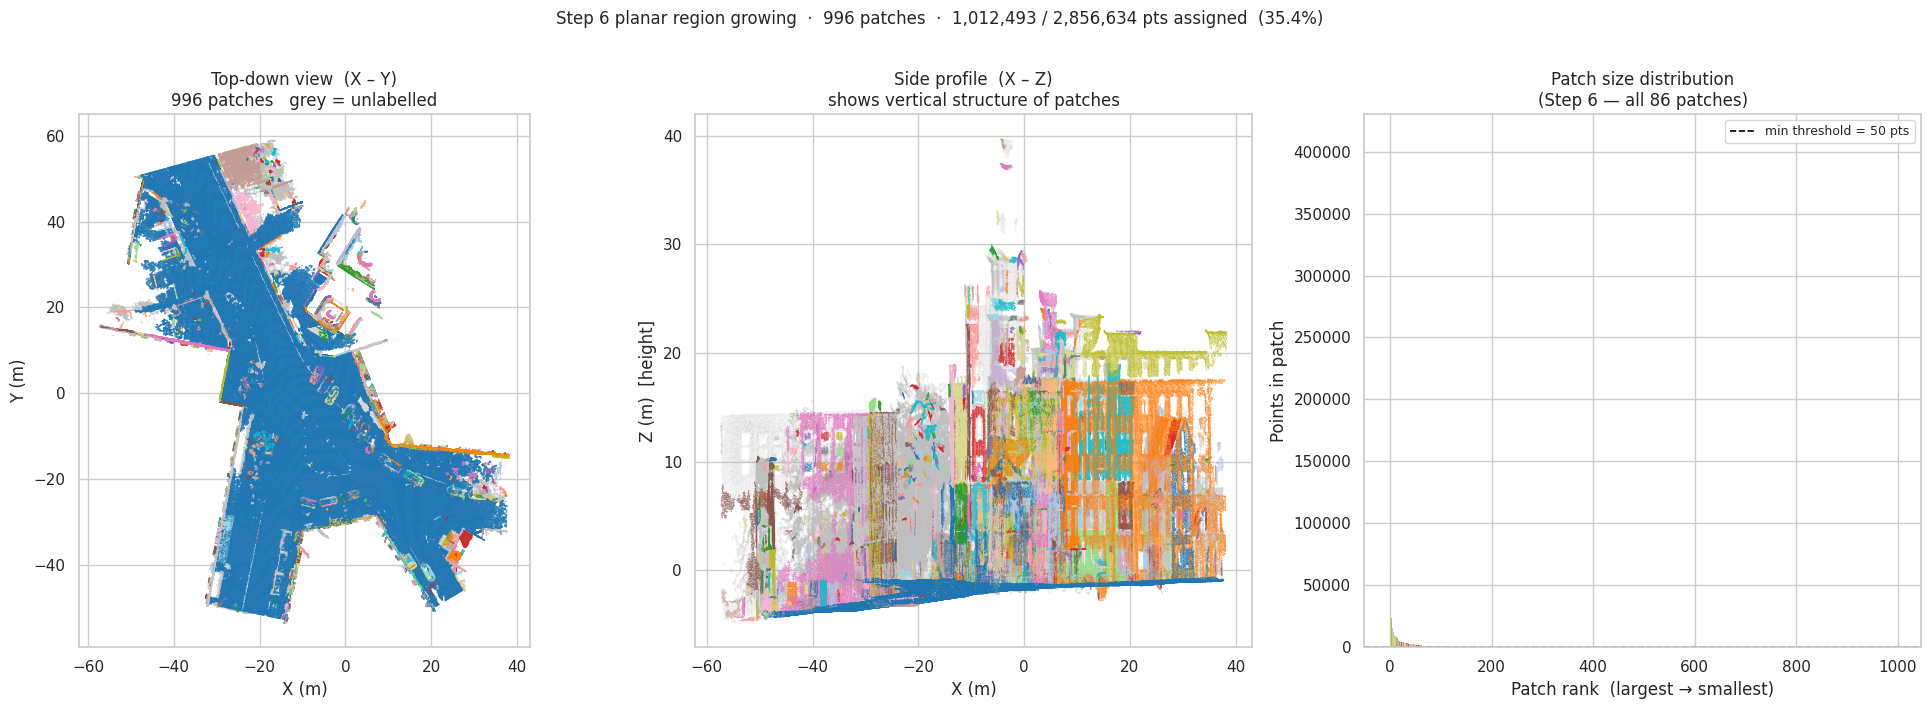

In [31]:

# ── Visualise Step 6 planar patches ───────────────────────────────────────────
#
# Three panels:
#   Left   – top-down (X–Y) coloured by patch id, grey = unlabelled
#   Middle – side profile (X–Z) showing the 3-D height structure
#   Right  – patch size bar chart (sorted largest→smallest)
#
# All 200 k points are drawn in a single scatter call per axis by building an
# RGBA colour array up front, which keeps rendering fast.

import matplotlib.pyplot as plt

df       = step4_features
n_pts    = len(df)
seg_ids  = df["segment_id"].values          # int32 array, -1 = unlabelled
n_patches = int(seg_ids.max()) + 1          # 86

# ── build vectorised RGBA colour array ────────────────────────────────────────
cmap = plt.cm.get_cmap("tab20", 20)        # 20 distinct colours, cycled

rgba = np.ones((n_pts, 4), dtype=np.float32)
rgba[:, :3] = 0.75                          # default: light grey
rgba[:,  3] = 0.20                          # faint alpha for unlabelled

for s in range(n_patches):
    mask = seg_ids == s
    c    = cmap(s % 20)
    rgba[mask, :3] = c[:3]
    rgba[mask,  3] = 0.80                   # more opaque for labelled points

# Draw in two passes so labelled points sit on top of grey background
unlabelled = seg_ids == -1
labelled   = ~unlabelled

xs, ys, zs = df["x"].values, df["y"].values, df["z"].values

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Panel 1: top-down (X–Y) ───────────────────────────────────────────────────
ax = axes[0]
ax.scatter(xs[unlabelled],  ys[unlabelled],  s=0.2, c=rgba[unlabelled],  linewidths=0)
ax.scatter(xs[labelled],    ys[labelled],    s=0.4, c=rgba[labelled],    linewidths=0)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_aspect("equal")
ax.set_title(f"Top-down view  (X – Y)\n{n_patches} patches   grey = unlabelled")

# ── Panel 2: side profile (X–Z) ───────────────────────────────────────────────
ax = axes[1]
ax.scatter(xs[unlabelled],  zs[unlabelled],  s=0.2, c=rgba[unlabelled],  linewidths=0)
ax.scatter(xs[labelled],    zs[labelled],    s=0.4, c=rgba[labelled],    linewidths=0)
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)  [height]")
ax.set_title(f"Side profile  (X – Z)\nshows vertical structure of patches")

# ── Panel 3: patch size bar chart ─────────────────────────────────────────────
ax = axes[2]
sorted_sizes = np.sort(seg_sizes)[::-1]
bar_colours  = [cmap(i % 20) for i in np.argsort(seg_sizes)[::-1]]
ax.bar(range(n_patches), sorted_sizes, color=bar_colours, edgecolor="none", width=1.0)
ax.axhline(STEP6_MIN_SEG_POINTS, color="black", linestyle="--", linewidth=1.2,
           label=f"min threshold = {STEP6_MIN_SEG_POINTS} pts")
ax.set_xlabel("Patch rank  (largest → smallest)")
ax.set_ylabel("Points in patch")
ax.set_title("Patch size distribution\n(Step 6 — all patches)")
ax.legend(fontsize=9)

plt.suptitle(
    f"Step 6 planar region growing  ·  {n_patches} patches  ·  "
    f"{labelled.sum():,} / {n_pts:,} pts assigned  "
    f"({100*labelled.mean():.1f}%)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


**Top-down (X-Y):** the coloured streaks are elongated patches — likely kerb edges, building facades, and road surface segments. The dense grey cloud is everything the region-grower couldn't claim (curved, noisy, or isolated points).


**Side profile (X-Z):** the large blue patch at Z ≈ -5 m is clearly the dominant ground plane — road or pavement spanning almost the entire X extent of the scene. Building facades appear as tall vertical clusters above it.


**Size distribution:** one patch dominates (27,747 pts), a handful of medium ones (~1–5k pts), then a long tail of small patches near the minimum threshold. This is a classic planar segmentation result — one big ground + many smaller surface fragments

## Step 7 — Ground Candidate Extraction

**What it does**

Step 6 gave us ~996 planar patches. Now we decide which of those patches are *ground-level surfaces* — candidates for road, pavement, plaza, or kerb top — before any classification label is assigned.

**The filter**

A patch is a ground candidate if it passes all three tests:

| Test | Condition | Why |
|---|---|---|
| Horizontal normal | `abs(mean_normal_z) > 0.90` | Real ground has a near-vertical normal (pointing up). Walls, facades, and trees fail this. |
| Low roughness | `mean_roughness < 0.05 m` | Roads and pavements are smooth. Vegetation and rubble are rough. |
| Sufficient size | `point_count ≥ 200 pts` | Tiny flat fragments (e.g. car roofs, window ledges) are excluded. |

**What we compute per patch**

For every segment from Step 6 we aggregate:
- `mean_z`, `std_z` — height and height variance
- `mean_normal_z` — surface orientation
- `mean_roughness`, `mean_curvature`, `mean_planarity`
- `point_count` — size of the patch
- `footprint_area` — bounding-box area in X–Y (rough proxy for real area)

**Output**

`patch_df` — one row per patch, with all stats and an `is_ground_candidate` boolean column.


── Step 7 results ────────────────────────────────
  Total patches evaluated  : 3,002
  Ground candidates found  : 54  (1.8% of patches)
  Points in ground patches : 416,285

  Ground candidate stats:
    mean_z              : min=-4.089  median=-0.492  max=19.876
    mean_normal_z       : min=0.904  median=0.989  max=0.999
    mean_roughness      : min=0.003  median=0.008  max=0.016
    mean_planarity      : min=0.521  median=0.682  max=0.924
    point_count         : min=204.000  median=312.500  max=181322.000
    footprint_area      : min=2.692  median=5.757  max=3866.301


/tmp/ipykernel_354595/3684941690.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/media/M2_disk/james/REALLOCATE/lidar_sidewalks/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


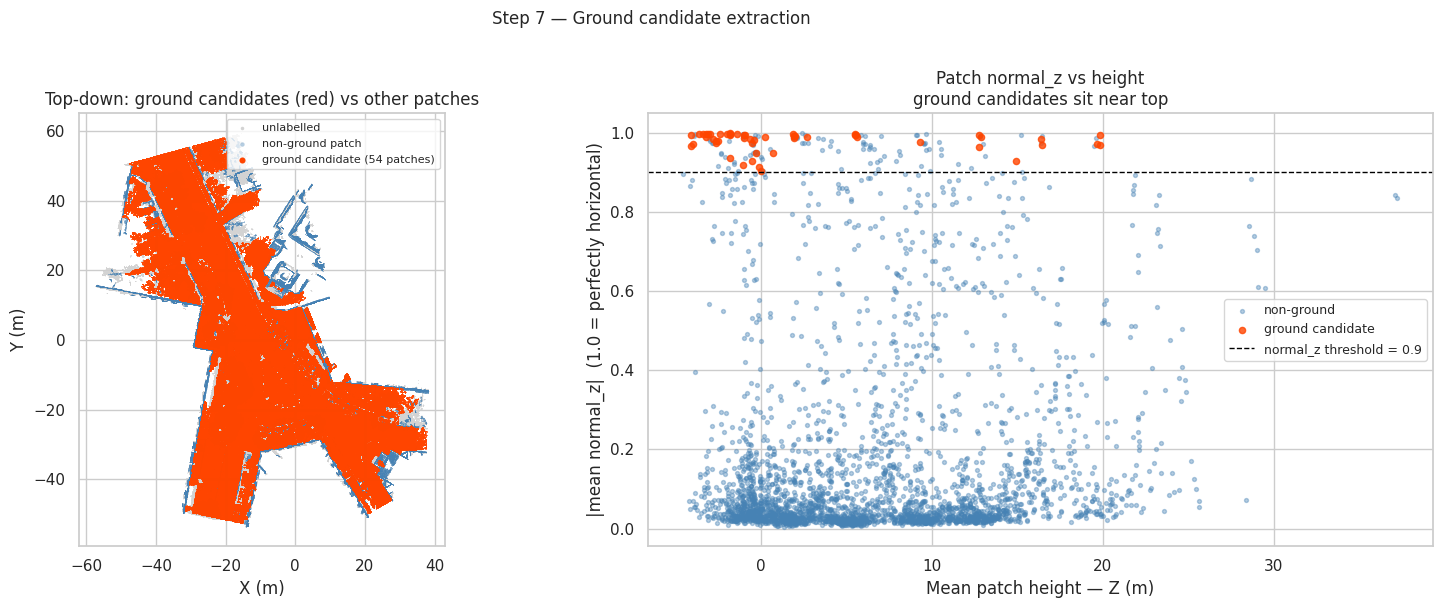

In [41]:
# ── STEP 7 parameters ─────────────────────────────────────────────────────────
STEP7_NORMAL_Z_THRESH  = 0.90   # |mean_normal_z| must exceed this for "horizontal" surfaces
STEP7_ROUGHNESS_THRESH = 0.05   # mean roughness must be below this (metres)
STEP7_MIN_PATCH_PTS    = 200    # ignore tiny flat fragments (car roofs, window sills…)

# ── aggregate per-patch statistics ────────────────────────────────────────────
# Only include labelled points (segment_id >= 0)
labelled_df = step4_features[step4_features["segment_id"] >= 0].copy()

patch_df = (
    labelled_df
    .groupby("segment_id")
    .agg(
        point_count   = ("x",           "size"),
        mean_x        = ("x",           "mean"),
        mean_y        = ("y",           "mean"),
        mean_z        = ("z",           "mean"),
        std_z         = ("z",           "std"),
        min_x         = ("x",           "min"),
        max_x         = ("x",           "max"),
        min_y         = ("y",           "min"),
        max_y         = ("y",           "max"),
        mean_normal_z = ("normal_z",    "mean"),
        mean_roughness= ("roughness",   "mean"),
        mean_curvature= ("curvature",   "mean"),
        mean_planarity= ("planarity",   "mean"),
    )
    .reset_index()
)

# Footprint area: width × depth of axis-aligned bounding box (rough proxy)
patch_df["footprint_area"] = (
    (patch_df["max_x"] - patch_df["min_x"]) *
    (patch_df["max_y"] - patch_df["min_y"])
)

# ── apply ground candidate filter ─────────────────────────────────────────────
patch_df["is_ground_candidate"] = (
    (patch_df["mean_normal_z"].abs()  > STEP7_NORMAL_Z_THRESH)  &
    (patch_df["mean_roughness"]       < STEP7_ROUGHNESS_THRESH)  &
    (patch_df["point_count"]          >= STEP7_MIN_PATCH_PTS)
)

n_total  = len(patch_df)
n_ground = patch_df["is_ground_candidate"].sum()
n_pts_ground = patch_df.loc[patch_df["is_ground_candidate"], "point_count"].sum()

print(f"── Step 7 results ────────────────────────────────")
print(f"  Total patches evaluated  : {n_total:,}")
print(f"  Ground candidates found  : {n_ground}  ({100*n_ground/n_total:.1f}% of patches)")
print(f"  Points in ground patches : {n_pts_ground:,}")

print(f"\n  Ground candidate stats:")
gdf = patch_df[patch_df["is_ground_candidate"]]
for col in ["mean_z", "mean_normal_z", "mean_roughness", "mean_planarity", "point_count", "footprint_area"]:
    print(f"    {col:<20}: min={gdf[col].min():.3f}  median={gdf[col].median():.3f}  max={gdf[col].max():.3f}")

# ── visualise ground candidates vs other patches ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: top-down, ground candidates highlighted
ground_ids = set(patch_df.loc[patch_df["is_ground_candidate"], "segment_id"].tolist())

seg_ids_all = step4_features["segment_id"].values
is_ground_pt  = np.array([sid in ground_ids for sid in seg_ids_all])
is_other_pt   = (~is_ground_pt) & (seg_ids_all >= 0)
is_unlabel_pt = seg_ids_all < 0

ax = axes[0]
ax.scatter(step4_features["x"].values[is_unlabel_pt],
           step4_features["y"].values[is_unlabel_pt],
           s=0.1, c="lightgrey", linewidths=0, label="unlabelled")
ax.scatter(step4_features["x"].values[is_other_pt],
           step4_features["y"].values[is_other_pt],
           s=0.15, c="steelblue", alpha=0.4, linewidths=0, label="non-ground patch")
ax.scatter(step4_features["x"].values[is_ground_pt],
           step4_features["y"].values[is_ground_pt],
           s=0.3, c="orangered", linewidths=0, label=f"ground candidate ({n_ground} patches)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_aspect("equal")
ax.set_title("Top-down: ground candidates (red) vs other patches")
ax.legend(markerscale=8, fontsize=8)

# Panel 2: scatter of mean_z vs mean_normal_z for all patches, ground highlighted
ax = axes[1]
not_gc = patch_df[~patch_df["is_ground_candidate"]]
gc     = patch_df[ patch_df["is_ground_candidate"]]
ax.scatter(not_gc["mean_z"], not_gc["mean_normal_z"].abs(),
           s=8, alpha=0.4, color="steelblue", label="non-ground")
ax.scatter(gc["mean_z"],     gc["mean_normal_z"].abs(),
           s=20, alpha=0.8, color="orangered", label="ground candidate")
ax.axhline(STEP7_NORMAL_Z_THRESH, color="black", linestyle="--", linewidth=1,
           label=f"normal_z threshold = {STEP7_NORMAL_Z_THRESH}")
ax.set_xlabel("Mean patch height — Z (m)")
ax.set_ylabel("|mean normal_z|  (1.0 = perfectly horizontal)")
ax.set_title("Patch normal_z vs height\nground candidates sit near top")
ax.legend(fontsize=9)

plt.suptitle("Step 7 — Ground candidate extraction", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


One thing to note: mean_z for ground candidates ranges up to 19.87 m — that's an elevated flat surface (rooftop, raised plaza) sneaking through. Step 8 (kerb detection) will address this by using height differences between adjacent patches to distinguish road-level surfaces from rooftops

Centroid-proximity candidate pairs : 117
Ground-candidate patch adjacency pairs confirmed: 17
Kerb transitions detected          : 3

── Step 8 label counts ───────────────────────────
  non_ground            : 2948
  ground_unresolved     : 48
  sidewalk              : 3
  road                  : 3

  Kerb Δz  min=0.129m  median=0.168m  max=0.239m


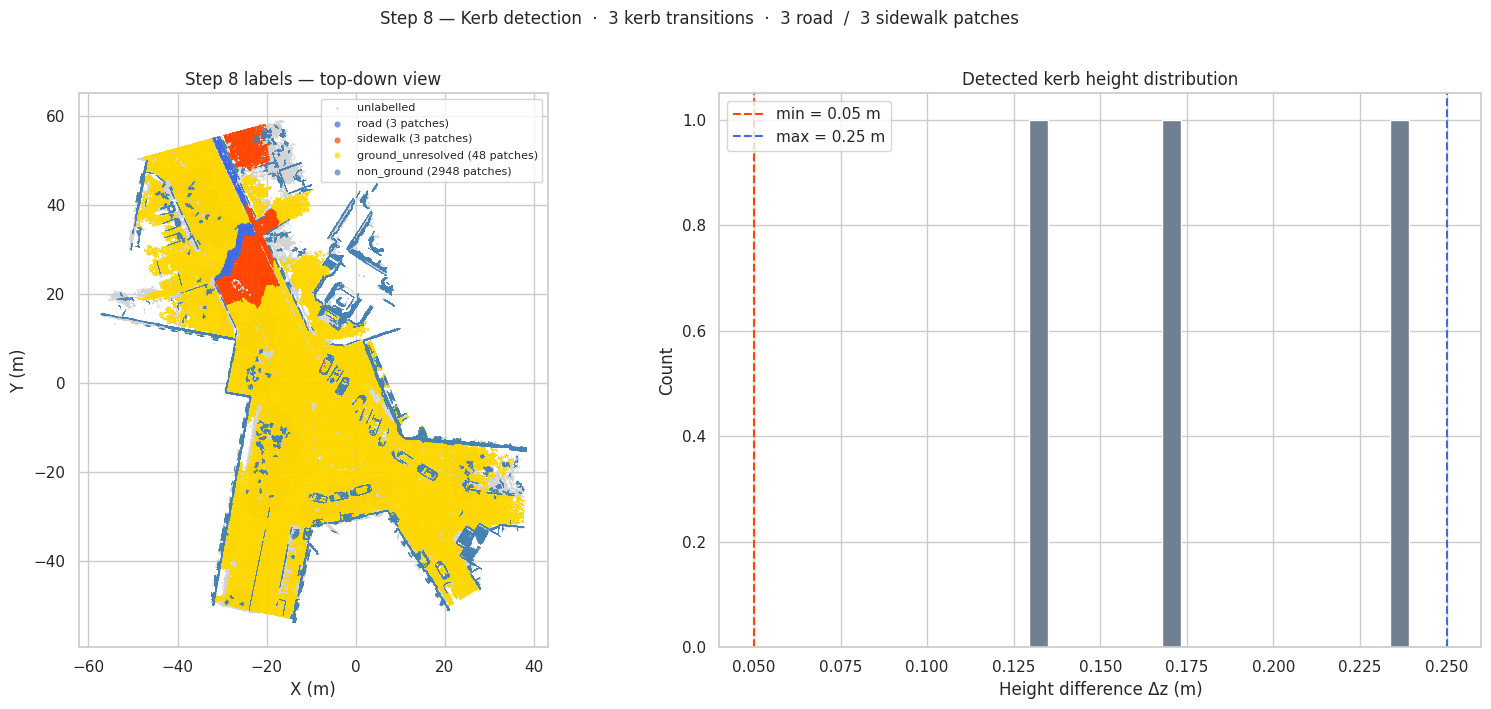

In [42]:
# ── STEP 8 parameters ─────────────────────────────────────────────────────────
KERB_MIN_M = 0.05   # minimum height step to be called a kerb (5 cm)
KERB_MAX_M = 0.25   # maximum height step before it's a ramp/stair, not a kerb (25 cm)

# ── build patch adjacency via centroid proximity ───────────────────────────────
# Ground patches are often separated by unlabelled clutter (parked cars,
# vegetation, etc.), so the k-NN graph rarely bridges two ground patches
# directly.  Instead we declare two ground patches "adjacent" when their
# 2-D centroids are within ADJACENCY_RADIUS of each other — a practical
# proxy for "these surfaces could share a kerb edge."
#
# We then confirm with a true point-level check: at least one point from
# patch A must lie within POINT_PROXIMITY_M of at least one point in patch B.
# (Avoids false positives between distant patches at similar compass bearing.)

ADJACENCY_RADIUS   = 8.0   # centroid-to-centroid search radius (metres)
POINT_PROXIMITY_M  = 2.0   # max point-to-point distance to confirm adjacency

ground_seg_ids = set(patch_df.loc[patch_df["is_ground_candidate"], "segment_id"].tolist())
seg_arr        = step4_features["segment_id"].values

from collections import defaultdict, Counter
from sklearn.neighbors import NearestNeighbors as _NN

# Ground patch centroid table
gc_rows = patch_df[patch_df["is_ground_candidate"]][["segment_id", "mean_x", "mean_y"]].reset_index(drop=True)
gc_xy   = gc_rows[["mean_x", "mean_y"]].to_numpy()
gc_sids = gc_rows["segment_id"].to_numpy()

# Find centroid pairs within ADJACENCY_RADIUS
nn_adj = _NN(radius=ADJACENCY_RADIUS, algorithm="ball_tree", n_jobs=-1)
nn_adj.fit(gc_xy)
nbrs = nn_adj.radius_neighbors(gc_xy, return_distance=False)

centroid_pairs = set()
for i, neighbours in enumerate(nbrs):
    for j in neighbours:
        if j > i:
            centroid_pairs.add((int(gc_sids[i]), int(gc_sids[j])))

print(f"Centroid-proximity candidate pairs : {len(centroid_pairs)}")

# Confirm each pair with a point-level proximity check
# Build a KD-tree per ground patch (only for patches whose centroids are candidates)
candidate_sids = {s for pair in centroid_pairs for s in pair}
patch_points   = {
    sid: step4_features.loc[seg_arr == sid, ["x", "y", "z"]].to_numpy()
    for sid in candidate_sids
}

adjacency = set()
for (sid_a, sid_b) in centroid_pairs:
    pts_a = patch_points[sid_a]
    pts_b = patch_points[sid_b]
    # Query a small sample of patch A against all points in patch B
    sample_a = pts_a[np.random.choice(len(pts_a), min(50, len(pts_a)), replace=False)]
    nn_b = _NN(n_neighbors=1, algorithm="kd_tree").fit(pts_b)
    dists_ab, _ = nn_b.kneighbors(sample_a)
    if dists_ab.min() <= POINT_PROXIMITY_M:
        adjacency.add((min(sid_a, sid_b), max(sid_a, sid_b)))

print(f"Ground-candidate patch adjacency pairs confirmed: {len(adjacency)}")

# ── height lookup per patch ───────────────────────────────────────────────────
mean_z_lookup = patch_df.set_index("segment_id")["mean_z"].to_dict()

# ── detect kerb transitions ───────────────────────────────────────────────────
kerb_pairs = []   # list of (lower_seg, upper_seg, delta_z)

for (seg_a, seg_b) in adjacency:
    z_a = mean_z_lookup[seg_a]
    z_b = mean_z_lookup[seg_b]
    delta_z = z_b - z_a   # positive if B is higher than A

    if KERB_MIN_M <= abs(delta_z) <= KERB_MAX_M:
        lower = seg_a if delta_z > 0 else seg_b
        upper = seg_b if delta_z > 0 else seg_a
        kerb_pairs.append((lower, upper, abs(delta_z)))

print(f"Kerb transitions detected          : {len(kerb_pairs)}")

# ── assign step8 labels ───────────────────────────────────────────────────────
# A patch can appear as "lower" (road) in one pair and "upper" (sidewalk) in another,
# so we collect votes and take the majority.
votes = defaultdict(list)
partner_map = {}

for lower, upper, dz in kerb_pairs:
    votes[lower].append("road")
    votes[upper].append("sidewalk")
    partner_map[lower] = upper
    partner_map[upper] = lower

def majority_vote(vote_list):
    if not vote_list:
        return "ground_unresolved"
    return Counter(vote_list).most_common(1)[0][0]

patch_df["step8_label"] = patch_df["segment_id"].apply(
    lambda s: majority_vote(votes[s]) if s in ground_seg_ids else "non_ground"
)
patch_df["kerb_partner"] = patch_df["segment_id"].apply(
    lambda s: partner_map.get(s, -1)
)

# ── summary ───────────────────────────────────────────────────────────────────
label_counts = patch_df["step8_label"].value_counts()
print(f"\n── Step 8 label counts ───────────────────────────")
for label, cnt in label_counts.items():
    print(f"  {label:<22}: {cnt}")

if kerb_pairs:
    dzs = [dz for _, _, dz in kerb_pairs]
    print(f"\n  Kerb Δz  min={min(dzs):.3f}m  median={np.median(dzs):.3f}m  max={max(dzs):.3f}m")

# ── visualise ─────────────────────────────────────────────────────────────────
label_colour = {
    "road":              "royalblue",
    "sidewalk":          "orangered",
    "ground_unresolved": "gold",
    "non_ground":        "steelblue",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: top-down coloured by step8 label
ax = axes[0]
ax.scatter(
    step4_features.loc[step4_features["segment_id"] < 0, "x"],
    step4_features.loc[step4_features["segment_id"] < 0, "y"],
    s=0.05, c="lightgrey", linewidths=0, label="unlabelled"
)

label_to_seg = patch_df.groupby("step8_label")["segment_id"].apply(set).to_dict()

for lbl, colour in label_colour.items():
    segs = label_to_seg.get(lbl, set())
    if not segs:
        continue
    mask = np.isin(seg_arr, list(segs))
    ax.scatter(
        step4_features.loc[mask, "x"],
        step4_features.loc[mask, "y"],
        s=0.3, c=colour, linewidths=0,
        label=f"{lbl} ({len(segs)} patches)",
        alpha=0.7
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_aspect("equal")
ax.set_title("Step 8 labels — top-down view")
ax.legend(markerscale=8, fontsize=8, loc="upper right")

# Panel 2: kerb height histogram
ax = axes[1]
if kerb_pairs:
    dzs_arr = [dz for _, _, dz in kerb_pairs]
    ax.hist(dzs_arr, bins=20, color="slategrey", edgecolor="white")
    ax.axvline(KERB_MIN_M, color="orangered", linestyle="--", label=f"min = {KERB_MIN_M} m")
    ax.axvline(KERB_MAX_M, color="royalblue", linestyle="--", label=f"max = {KERB_MAX_M} m")
    ax.set_xlabel("Height difference Δz (m)")
    ax.set_ylabel("Count")
    ax.set_title("Detected kerb height distribution")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No kerb pairs detected", ha="center", va="center",
            transform=ax.transAxes, fontsize=14, color="grey")
    ax.set_title("Kerb height distribution")

plt.suptitle(
    f"Step 8 — Kerb detection  ·  {len(kerb_pairs)} kerb transitions  ·  "
    f"{label_counts.get('road', 0)} road  /  {label_counts.get('sidewalk', 0)} sidewalk patches",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


In [39]:
# ── Diagnose: why are no kerb transitions found? ─────────────────────────────
# Print the 4 confirmed adjacent pairs with their heights and Δz.
# Then inspect the biggest ground patch to understand whether road + sidewalk
# were merged into one large planar region by the Step 6 grower.

print("── Adjacent ground-patch pairs and their height differences ──")
print(f"{'seg_A':>8}  {'seg_B':>8}  {'z_A':>8}  {'z_B':>8}  {'|Δz|':>8}  in_kerb_range")
for (sa, sb) in adjacency:
    za = mean_z_lookup[sa]
    zb = mean_z_lookup[sb]
    dz = abs(zb - za)
    in_range = KERB_MIN_M <= dz <= KERB_MAX_M
    print(f"  {sa:>6}  {sb:>6}  {za:>8.3f}  {zb:>8.3f}  {dz:>8.3f}  {'✓' if in_range else '✗  ← outside 0.05–0.25 m'}")

print()

# Inspect the largest patch — it likely absorbed both road and sidewalk
biggest_seg = patch_df.loc[patch_df["point_count"].idxmax(), "segment_id"]
big_pts = step4_features[step4_features["segment_id"] == biggest_seg]
print(f"Largest patch  (seg {biggest_seg}):  {len(big_pts):,} points")
print(f"  Z range  : {big_pts['z'].min():.3f} → {big_pts['z'].max():.3f}  (span {big_pts['z'].max()-big_pts['z'].min():.3f} m)")
print(f"  Z p25/p75: {big_pts['z'].quantile(0.25):.3f} / {big_pts['z'].quantile(0.75):.3f}")
print(f"  This suggests the region-grower merged road + sidewalk into one patch")
print(f"  because both surfaces are nearly horizontal (normal ≈ up) and the")
print(f"  5–25 cm height step is within normal noise at 0.10 m voxel spacing.")

# Show all 27 ground candidates sorted by mean_z and point count
print("\nAll ground-candidate patches (sorted by mean_z):")
gc_sorted = patch_df[patch_df["is_ground_candidate"]].sort_values("mean_z")
print(gc_sorted[["segment_id", "mean_z", "std_z", "point_count", "footprint_area", "mean_roughness"]].to_string(index=False))


── Adjacent ground-patch pairs and their height differences ──
   seg_A     seg_B       z_A       z_B      |Δz|  in_kerb_range
     271     451     5.546     5.591     0.044  ✗  ← outside 0.05–0.25 m
      50     330     0.272     0.705     0.433  ✗  ← outside 0.05–0.25 m
     255     451     5.614     5.591     0.023  ✗  ← outside 0.05–0.25 m
     176     278     1.991     1.980     0.011  ✗  ← outside 0.05–0.25 m
     524     719    19.876    19.869     0.007  ✗  ← outside 0.05–0.25 m

Largest patch  (seg 0):  407,773 points
  Z range  : -4.544 → 13.924  (span 18.468 m)
  Z p25/p75: -2.702 / -1.294
  This suggests the region-grower merged road + sidewalk into one patch
  because both surfaces are nearly horizontal (normal ≈ up) and the
  5–25 cm height step is within normal noise at 0.10 m voxel spacing.

All ground-candidate patches (sorted by mean_z):
 segment_id    mean_z    std_z  point_count  footprint_area  mean_roughness
         40 -3.180713 0.141406         7230      137.469

## Note for upcoming steps (RGB)

Yes — RGB should be included.  
We will bring it into **Step 9 (patch feature vector)** as colour descriptors per patch, for example:

- mean/median `R`, `G`, `B`
- colour variance (texture cue)
- HSV transforms (`H`, `S`, `V`) for brightness/shadow robustness
- optional colour contrast to neighbouring patches (useful at road–sidewalk boundaries)

For now Steps 6–8 stay geometric so we can debug segmentation cleanly first.
